In [279]:
import numpy as np
import random
import pandas as pd
from tqdm import tqdm
import os

In [280]:
def create_pop(lengde):
    # Definer aldersintervaller og tilhørende sannsynligheter
    alder_intervaller = [
        (0, 4), (5, 9), (10, 14), (15, 19), (20, 24), (25, 29),
        (30, 34), (35, 39), (40, 44), (45, 49), (50, 54), (55, 59),
        (60, 64), (65, 69), (70, 74), (75, 79), (80, 84), (85, 89),
        (90, 94), (95, 99), (100, 104)
    ]
    
    sannsynligheter = [
        0.04974, 0.05486, 0.05956, 0.06003, 0.06034, 0.06653,
        0.07160, 0.06885, 0.06543, 0.06432, 0.06860, 0.06561,
        0.05785, 0.05281, 0.04631, 0.04137, 0.02441, 0.01356,
        0.00630, 0.00171, 0.00023
    ]

    # Normaliser sannsynlighetene slik at de summerer til 1
    total = sum(sannsynligheter)
    sannsynligheter = [s / total for s in sannsynligheter]

    # Velg aldersintervaller for populasjonen basert på sannsynligheter
    alder_valg = np.random.choice(
        range(len(alder_intervaller)), p=sannsynligheter, size=lengde
    )

    # Generer en spesifikk alder innenfor hvert valgt intervall
    alder = [
        random.randint(alder_intervaller[i][0], alder_intervaller[i][1])
        for i in alder_valg
    ]

    # Lag populasjonen
    population = {
        "sex": [random.choice(['K', 'M']) for _ in range(lengde)], 
        "alder": alder,
        "barn": [random.randint(1, 4) if alder[i] > 20 else 0 for i in range(lengde)]
    }

    df = pd.DataFrame(population)
    return df

# Generer en populasjon på 100,000 individer
populasjon = create_pop(100_000)
print(populasjon)

      sex  alder  barn
0       M      9     0
1       K     84     3
2       M     17     0
3       K     30     4
4       K      9     0
...    ..    ...   ...
99995   M     33     3
99996   M     68     4
99997   M     10     0
99998   M     64     3
99999   M      9     0

[100000 rows x 3 columns]


In [281]:
populasjon

,sex,alder,barn
0,M,9,0
1,K,84,3
2,M,17,0
3,K,30,4
4,K,9,0
...,...,...,...
99995,M,33,3
99996,M,68,4
99997,M,10,0
99998,M,64,3


In [282]:
populasjon['aldersgruppe'] = populasjon['alder'].apply(get_age_group)
populasjon

,sex,alder,barn,aldersgruppe
0,M,9,0,0-9
1,K,84,3,80-89
2,M,17,0,10-19
3,K,30,4,30-39
4,K,9,0,0-9
...,...,...,...,...
99995,M,33,3,30-39
99996,M,68,4,60-69
99997,M,10,0,10-19
99998,M,64,3,60-69


In [283]:
populasjon.loc[lambda x: x.alder > 100]

,sex,alder,barn,aldersgruppe
12508,M,102,3,100+
15128,K,101,4,100+
19681,K,103,3,100+
24150,M,103,2,100+
28179,K,103,3,100+
30646,M,103,3,100+
33843,K,104,3,100+
34699,K,103,1,100+
40234,M,102,1,100+
40594,K,102,4,100+


<Axes: xlabel='alder'>

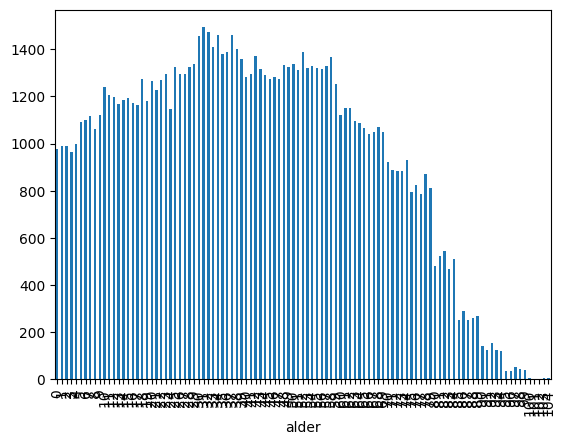

In [284]:
populasjon.alder.value_counts().sort_index().plot(kind="bar")

In [286]:
os.listdir(os.getcwd())

['Utforske befolkning og TFR.ipynb',
 'befolknings_14_til_fremskrivning.csv',
 'output.png',
 'befolkning_m_k.xlsx',
 'befolkningsfordeling.xlsx',
 'befolkning_2v.ipynb',
 'levendefodte_etter_alder.xlsx',
 'befolkning-Copy1.ipynb',
 'fødte.xlsx',
 'TFR_14_16_18_21_23_aar_1986_2144.csv',
 'asfr_norm_avg.csv',
 'TFR_14_21_27_aar_1986_2274.csv',
 'ny_befolkning_etter_1_4.csv',
 'befolkning.csv',
 'befolkning.ipynb',
 'tabell.csv',
 'asfr_2023.csv',
 'nettoinvandring.csv',
 'befolkning_fordeling.xlsx',
 '.ipynb_checkpoints',
 'befolkningsutviling_TFR1_4.csv']

In [299]:
asfr = pd.read_csv("asfr_avg.csv")
asfr.set_index("aldersgruppe", inplace=True)
asfr = (asfr.sum(axis=1) / len(asfr.columns)).reset_index().rename(columns={0:"asfr_norm_avg"})
asfr

,aldersgruppe,asfr_norm_avg
0,15-19 år,1.995243
1,20-24 år,27.014151
2,25-29 år,92.086207
3,30-34 år,113.822993
4,35-39 år,56.689086
5,40-44 år,11.724304
6,45-49 år,0.817962


<Axes: xlabel='aldersgruppe'>

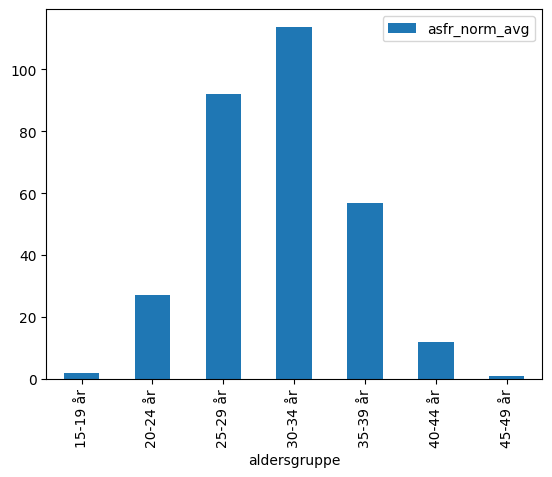

In [300]:
asfr.plot(x="aldersgruppe", y="asfr_norm_avg", kind="bar")

In [266]:
import pandas as pd
import random
from tqdm import tqdm

dødsrate = 0.008

def get_age_group(age):
    if age < 10:
        return '0-9'
    elif age < 20:
        return '10-19'
    elif age < 30:
        return '20-29'
    elif age < 40:
        return '30-39'
    elif age < 50:
        return '40-49'
    elif age < 60:
        return '50-59'
    elif age < 70:
        return '60-69'
    elif age < 80:
        return '70-79'
    elif age < 90:
        return '80-89'
    elif age < 100:
        return '90-99'
    else:
        return '100+'

# Definerer aldersgrupper og deres respektive vekter
age_groups = {
    '0-9': 0.00133,
    '10-19': 0.00080,
    '20-29': 0.00171,
    '30-39': 0.00276,
    '40-49': 0.00506,
    '50-59': 0.01196,
    '60-69': 0.03285,
    '70-79': 0.09724,
    '80-89': 0.33668,
    '90-99': 0.50960,
    '100+': 2
}

def create_pop(lengde):
    # Definer aldersintervaller og tilhørende sannsynligheter
    alder_intervaller = [
        (0, 4), (5, 9), (10, 14), (15, 19), (20, 24), (25, 29),
        (30, 34), (35, 39), (40, 44), (45, 49), (50, 54), (55, 59),
        (60, 64), (65, 69), (70, 74), (75, 79), (80, 84), (85, 89),
        (90, 94), (95, 99), (100, 104)
    ]
    
    sannsynligheter = [
        0.04974, 0.05486, 0.05956, 0.06003, 0.06034, 0.06653,
        0.07160, 0.06885, 0.06543, 0.06432, 0.06860, 0.06561,
        0.05785, 0.05281, 0.04631, 0.04137, 0.02441, 0.01356,
        0.00630, 0.00171, 0.00023
    ]

    # Normaliser sannsynlighetene slik at de summerer til 1
    total = sum(sannsynligheter)
    sannsynligheter = [s / total for s in sannsynligheter]

    # Velg aldersintervaller for populasjonen basert på sannsynligheter
    alder_valg = np.random.choice(
        range(len(alder_intervaller)), p=sannsynligheter, size=lengde
    )

    # Generer en spesifikk alder innenfor hvert valgt intervall
    alder = [
        random.randint(alder_intervaller[i][0], alder_intervaller[i][1])
        for i in alder_valg
    ]

    # Lag populasjonen
    population = {
        "sex": [random.choice(['K', 'M']) for _ in range(lengde)], 
        "alder": alder,
        "barn": [random.randint(1, 4) if alder[i] > 40 else 0 for i in range(lengde)]
    }

    df = pd.DataFrame(population)
    return df

def populasjonsutvikling(df, TFR, år, fruktbare_år, eldste_fødsel, innvandring=True,  innvandringsgrad=0.95):
    print(f"Regner populasjon med\nTFR={TFR}\nFruktbare år: {fruktbare_år}\nEldste fødsel: {eldste_fødsel}\n{år} år")
    
    liste_med_antall_personer = []
    sannsynlighet_for_barn = TFR / fruktbare_år
    
    for year in tqdm(range(år)):
        # Legger til 1 i alder på hele populasjonen
        df['alder'] += 1
        
        # Definerer fruktbare damer
        fruktbare_damer = df.loc[(df.alder > eldste_fødsel-fruktbare_år) & (df.alder < eldste_fødsel) & (df.barn < 4) & (df.sex == "K")]
        num_fruktbare_damer = len(fruktbare_damer)
        # Henter antall nye kids
        num_nye_kids = int(num_fruktbare_damer * sannsynlighet_for_barn)

        nye_kids = (
            pd.DataFrame({
                "sex": [random.choice(['K', 'M']) for _ in range(num_nye_kids)], 
                "alder": [0] * num_nye_kids,
                "barn": [0] * num_nye_kids}))
        
        # Øker antall barn for damene som får barn.
        df.loc[fruktbare_damer.sample(num_nye_kids, random_state=42).index, "barn"] += 1
        if "aldersgruppe" in df.columns:
            df = df.drop("aldersgruppe", axis=1)
        
        # Assign weights
        df['aldersgruppe'] = df['alder'].apply(get_age_group)
        # Disse vektene setter sannsynlighet for død
        df['vekter'] = df['aldersgruppe'].map(age_groups)
        
        # Regner ut antall døde personer
        antall_døde = int(len(df) * dødsrate)
        døde = df.sample(n=antall_døde, weights='vekter', random_state=42).index
        df = df.drop(døde)
        df = df.loc[lambda x: x.alder < 110]
        
        # Legger til innvandring i populasjonen
        if innvandring:
            if year in [0, 1]:
                innvandrere = 40_000
            else:
                innvandrere = int(40_000 * innvandringsgrad**year)
        else:
            innvandrere = 0

        innvandrere_df = create_pop(innvandrere)

        df = pd.concat([df, nye_kids, innvandrere_df]).reset_index(drop=True)
        df.drop(columns=['vekter'], inplace=True)

        liste_med_antall_personer.append(len(df))
        
    return liste_med_antall_personer, df

# Eksempel på bruk
initial_population = create_pop(5_540_000)
TFR = 1.8  # Total fertilitetsrate
år = 10
fruktbare_år = 35
eldste_fødsel = 50
populasjon_historie, endelig_populasjon = populasjonsutvikling(initial_population, TFR, år, fruktbare_år, eldste_fødsel)

print(populasjon_historie)

Regner populasjon med
TFR=1.8
Fruktbare år: 35
Eldste fødsel: 50
10 år


100% 10/10 [00:36<00:00,  3.66s/it]

[5595378, 5650865, 5702618, 5752764, 5801420, 5848685, 5894566, 5939180, 5982648, 6024380]


In [267]:
fordeling = endelig_populasjon.aldersgruppe.value_counts().sort_index().reset_index().rename(columns={"count":"antall"})

In [268]:
endelig_populasjon.aldersgruppe.value_counts()

aldersgruppe
40-49    813442
60-69    746213
50-59    745443
30-39    740341
20-29    697044
10-19    611535
0-9      571968
70-79    566886
80-89    336171
90-99     98749
100+       6987
Name: count, dtype: int64

In [269]:
fordeling

,aldersgruppe,antall
0,0-9,571968
1,10-19,611535
2,100+,6987
3,20-29,697044
4,30-39,740341
5,40-49,813442
6,50-59,745443
7,60-69,746213
8,70-79,566886
9,80-89,336171


In [270]:
import matplotlib.pyplot as plt

<BarContainer object of 11 artists>

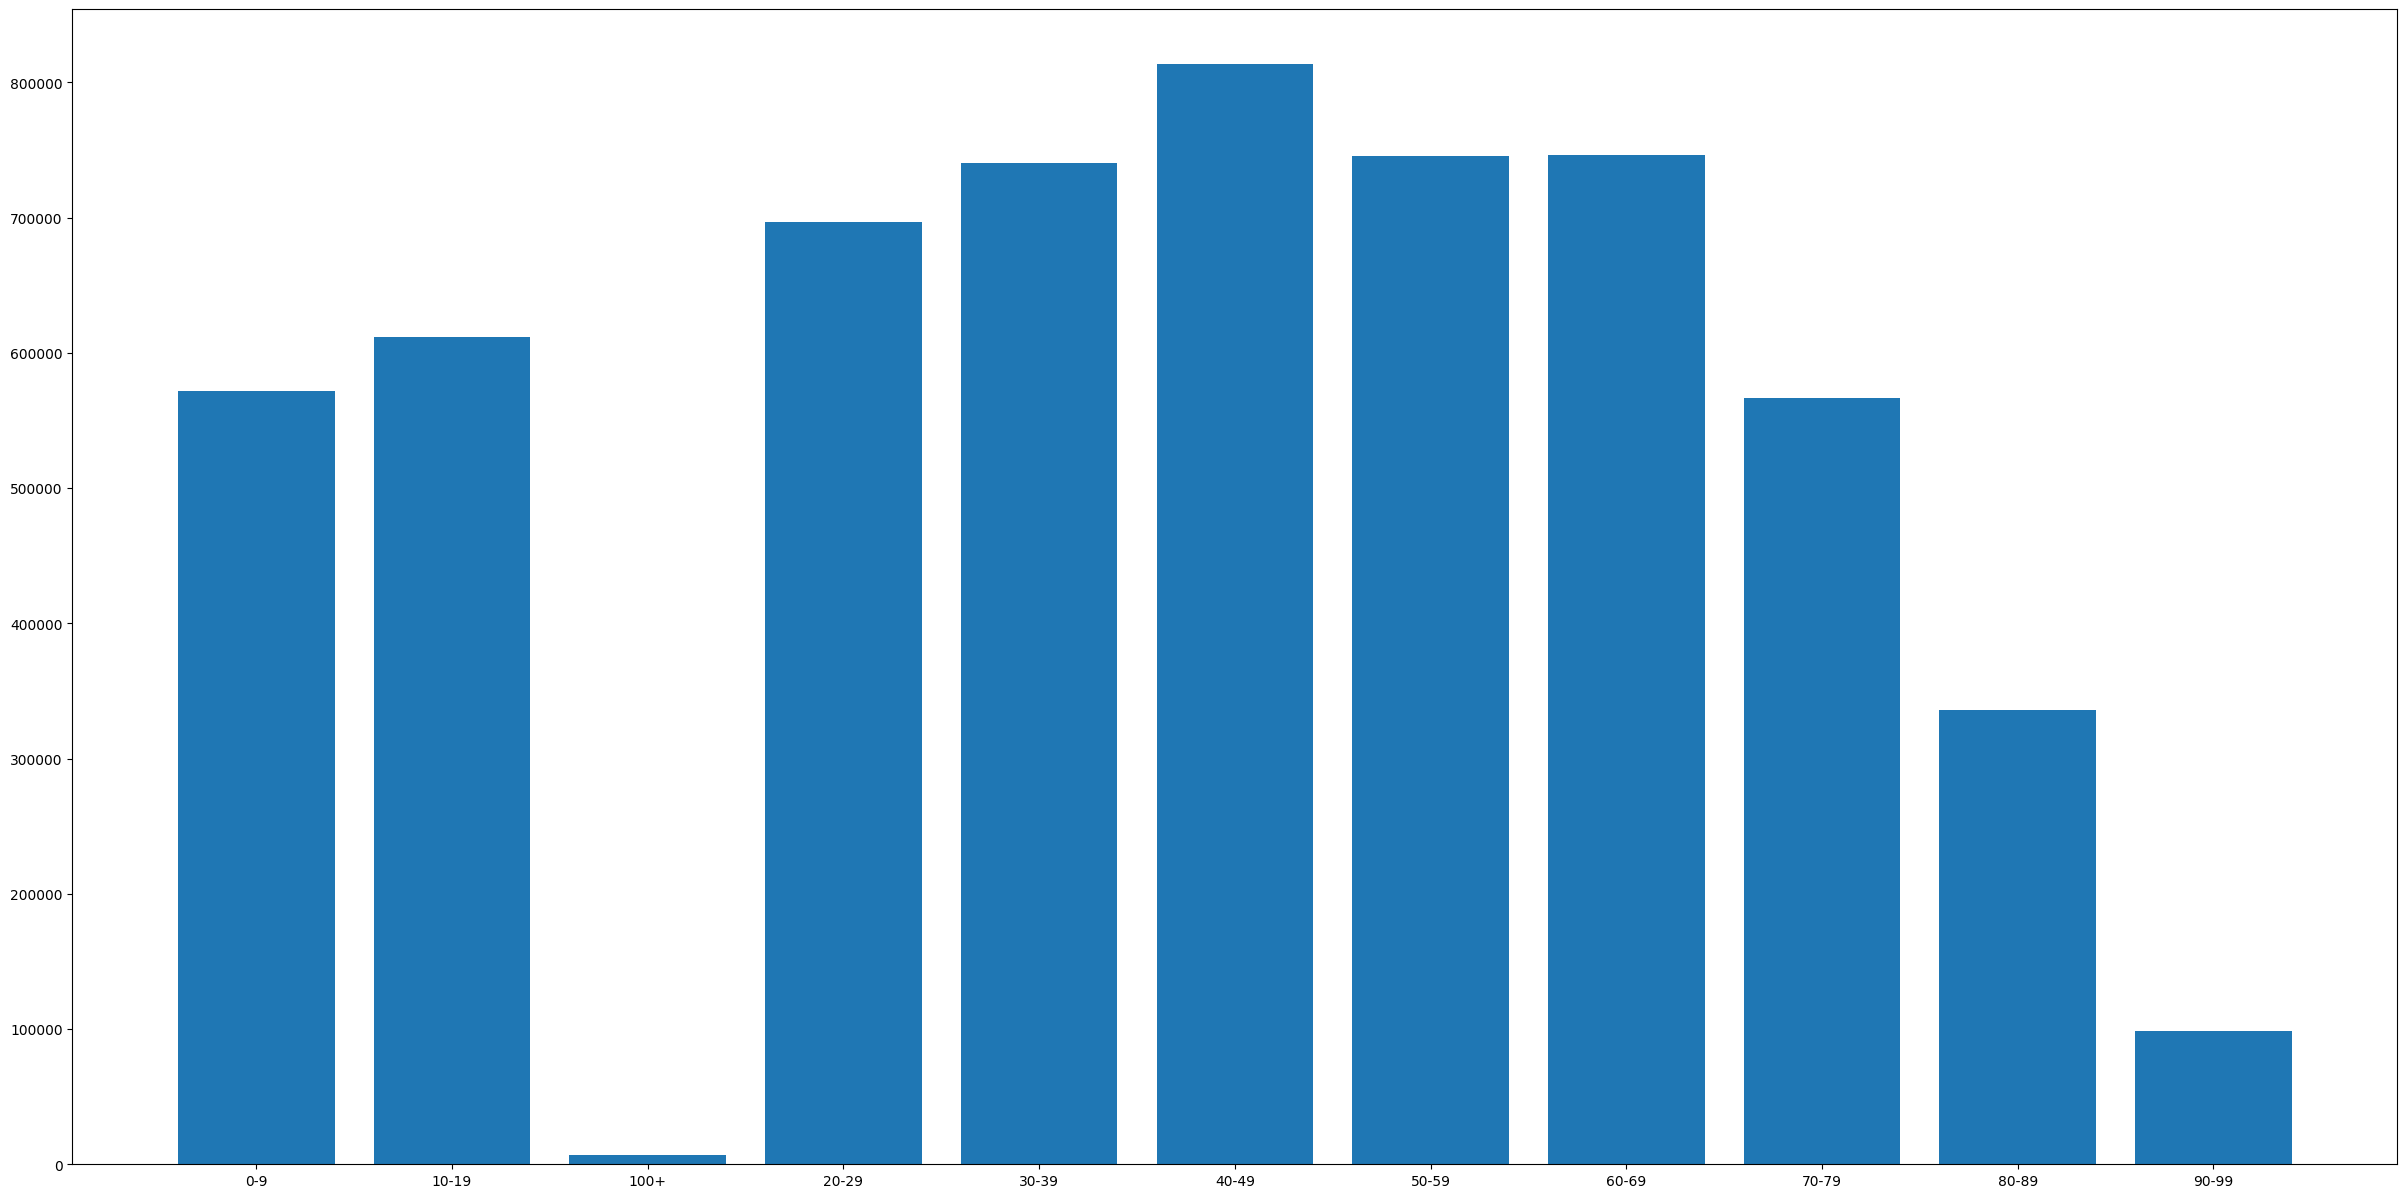

In [271]:
plt.figure(figsize=(30, 15))
plt.bar(list(fordeling.aldersgruppe), fordeling.antall)

In [272]:
befolkning_for_2023 = pd.read_csv("befolkning.csv")#.loc[lambda x: x.år <= 2022]

In [273]:
start_pop = befolkning_for_2023.loc[lambda x: x.år == 2024, "pop"].values[0]
start_pop

5550203

<Axes: xlabel='år'>

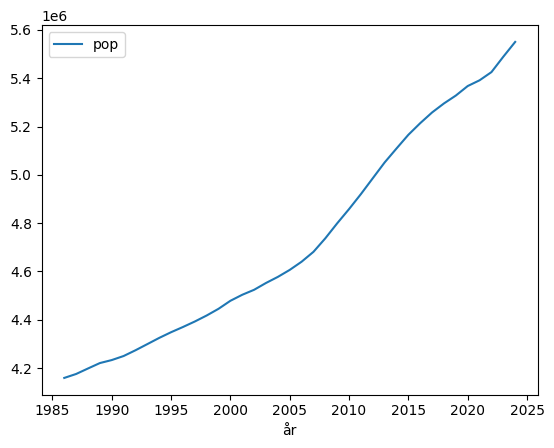

In [274]:
befolkning_for_2023.plot(x="år")

In [275]:
# Demonstrasjon av Norge
befolkningsutvikling = pd.DataFrame()
år_start = 1986
år = 30
år_slutt = (år_start) + (2025 - år_start) + år
fruktbare_år = 15
eldste_fødsel = 35
befolkningsutvikling["år"] = range(år_start, år_slutt)
# befolkningsutvikling


In [276]:
tfrs = [1.4]

for tfr in tfrs:
    df_for_run = create_pop(start_pop)
    utvikling, df = populasjonsutvikling(df_for_run, tfr, år, fruktbare_år, eldste_fødsel)
    utvikling = pd.concat([befolkning_for_2023["pop"], pd.Series(utvikling)]).reset_index(drop=True)
    befolkningsutvikling[f"pop_{tfr}"] = utvikling


Regner populasjon med
TFR=1.4
Fruktbare år: 15
Eldste fødsel: 35
30 år


100% 30/30 [01:56<00:00,  3.87s/it]


<Axes: xlabel='år'>

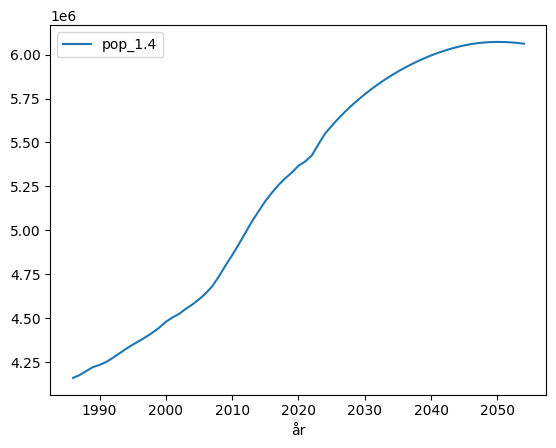

In [277]:
(
    befolkningsutvikling
   # .loc[lambda x: x.år < 2100]
    
    .plot(x="år", y = befolkningsutvikling.columns[1]))

In [254]:
df

,sex,alder,barn,aldersgruppe
0,M,77,4,70-79
1,K,81,4,80-89
2,M,44,0,40-49
3,K,90,1,90-99
4,M,42,0,40-49
...,...,...,...,...
5948649,K,80,1,NaN
5948650,K,17,0,NaN
5948651,K,55,1,NaN
5948652,M,5,0,NaN


In [255]:
df["aldersgruppe"] = df.alder.apply(get_age_group)

In [256]:
df.aldersgruppe.value_counts()

aldersgruppe
60-69    830295
50-59    775726
40-49    739716
70-79    720279
30-39    653282
80-89    590976
10-19    458331
20-29    421081
0-9      375658
90-99    307672
100+      75638
Name: count, dtype: int64

<BarContainer object of 11 artists>

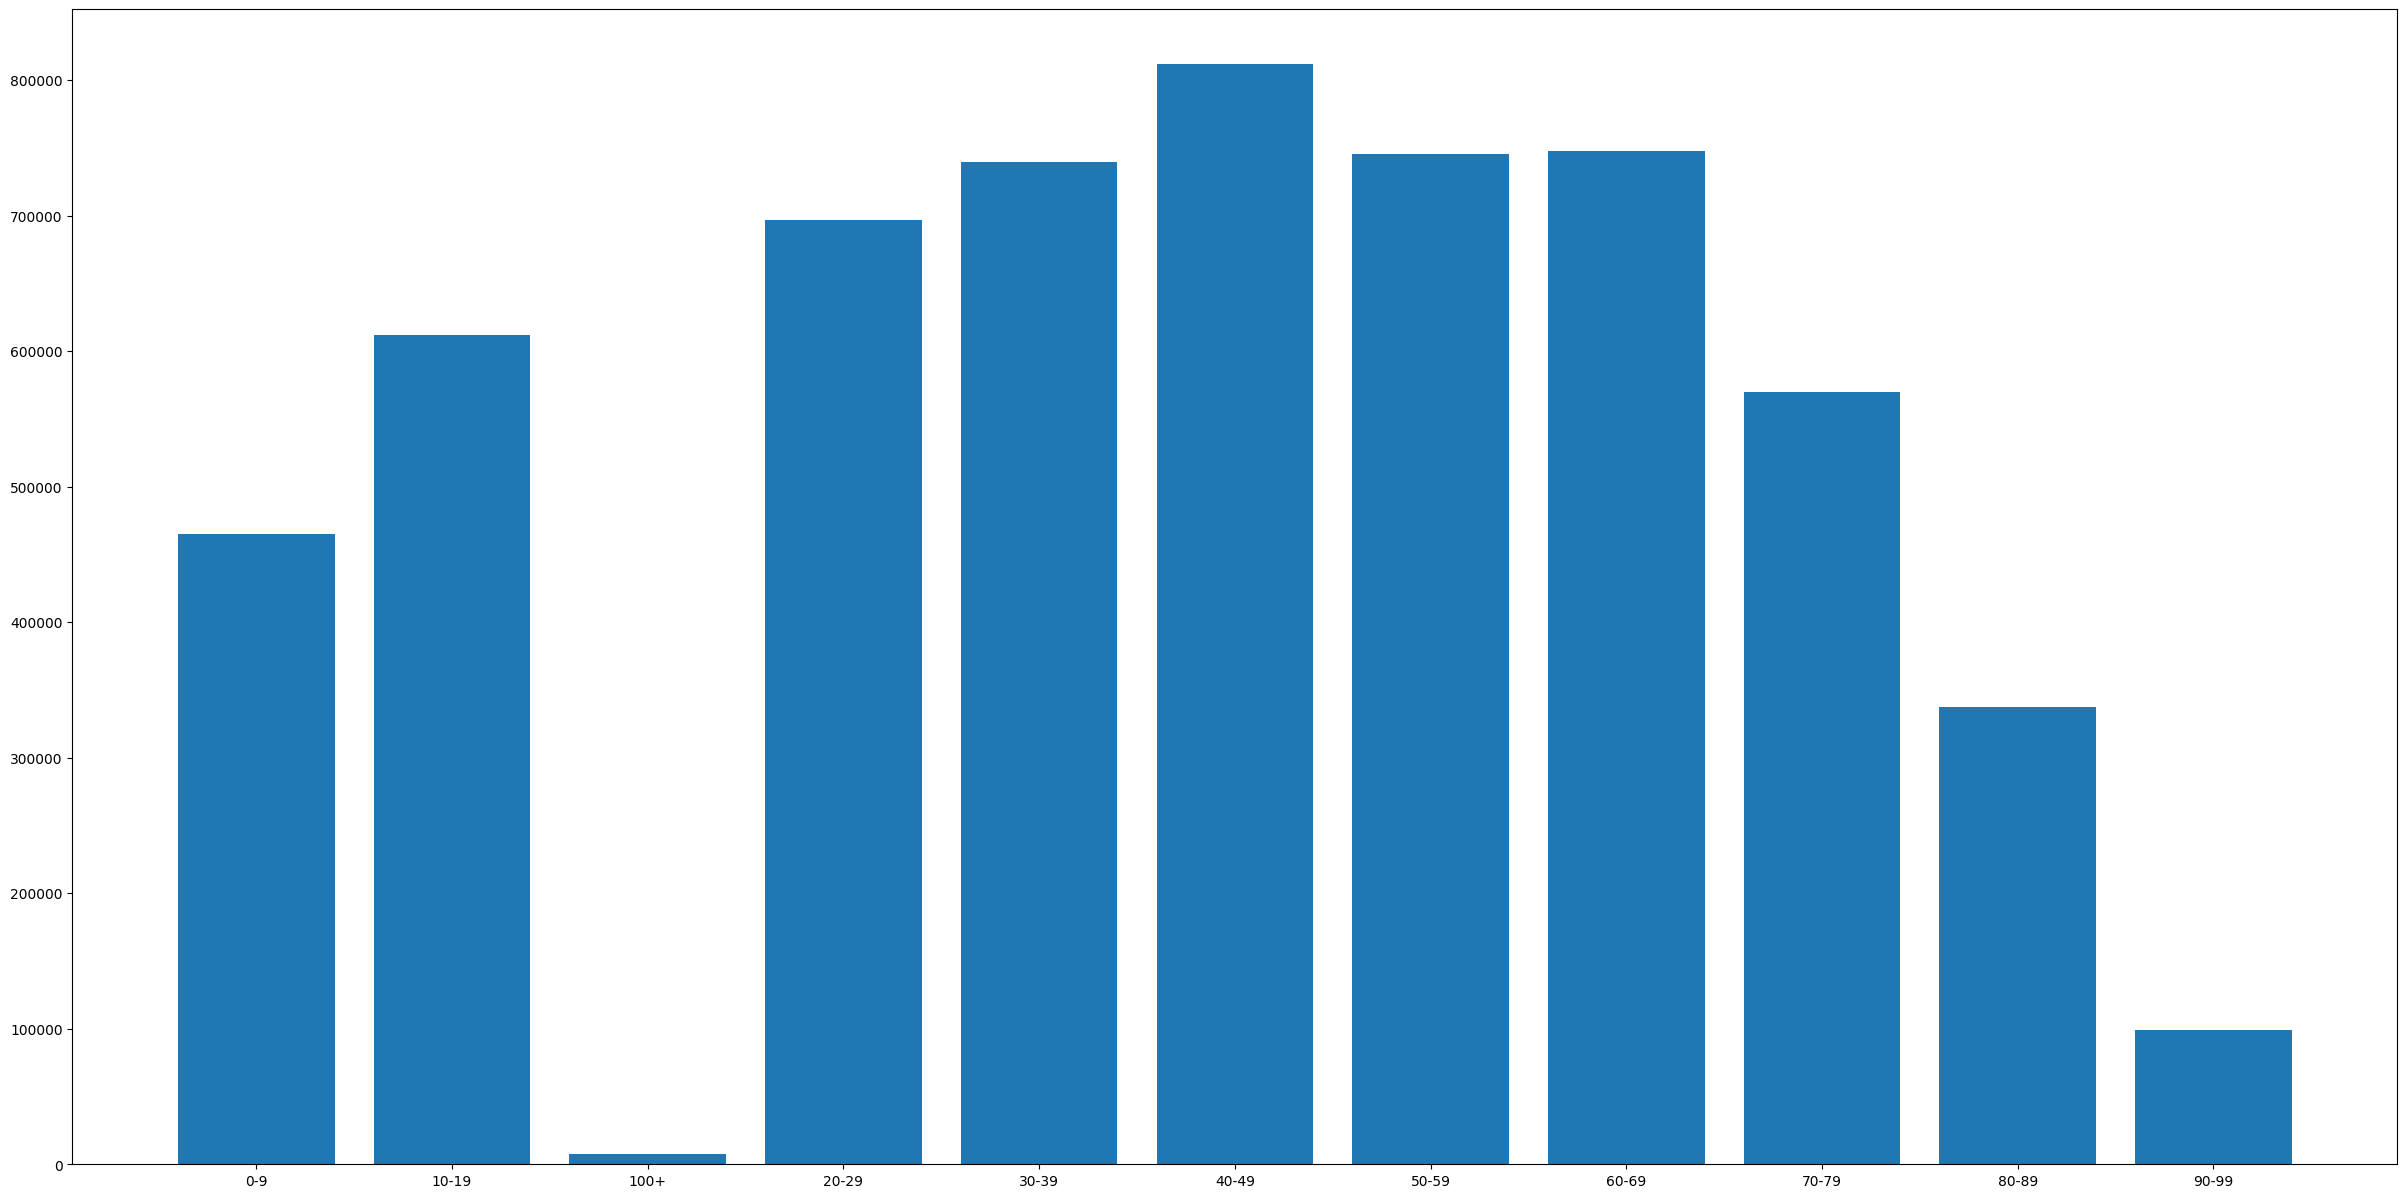

In [257]:
plt.figure(figsize=(30, 15))
plt.bar(list(fordeling.aldersgruppe), fordeling.antall)

In [264]:
fordeling = df_for_run.alder.value_counts().sort_index().reset_index().rename(columns={"count":"antall"})
fordeling

,alder,antall
0,1,55351
1,2,55432
2,3,55019
3,4,55329
4,5,55341
...,...,...
100,101,233
101,102,253
102,103,246
103,104,263


In [258]:
fordeling_etter = df.alder.value_counts().sort_index().reset_index().rename(columns={"count":"antall"})
fordeling_etter

,alder,antall
0,0,31733
1,1,32920
2,2,34135
3,3,35399
4,4,36681
...,...,...
105,105,5577
106,106,4434
107,107,3485
108,108,2860


In [259]:
fordeling_etter.tail(15)

,alder,antall
95,95,28098
96,96,26589
97,97,24561
98,98,22779
99,99,21420
100,100,16148
101,101,13311
102,102,11024
103,103,9140
104,104,7458


<Axes: xlabel='alder'>

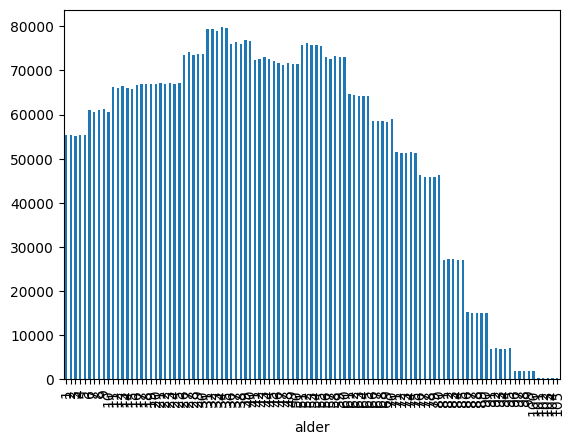

In [260]:
df_for_run.alder.value_counts().sort_index().plot(kind="bar")

<Axes: xlabel='alder'>

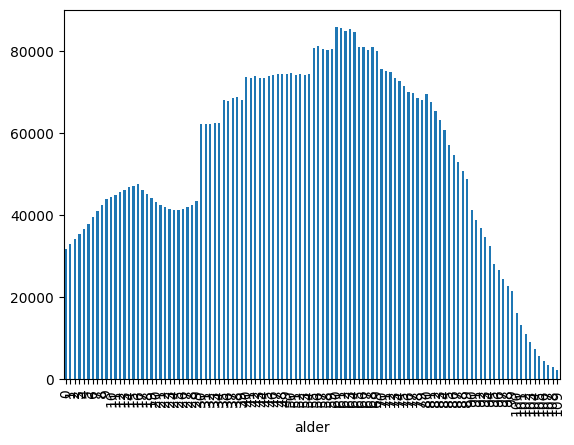

In [261]:
df.alder.value_counts().sort_index().plot(kind="bar")

<BarContainer object of 105 artists>

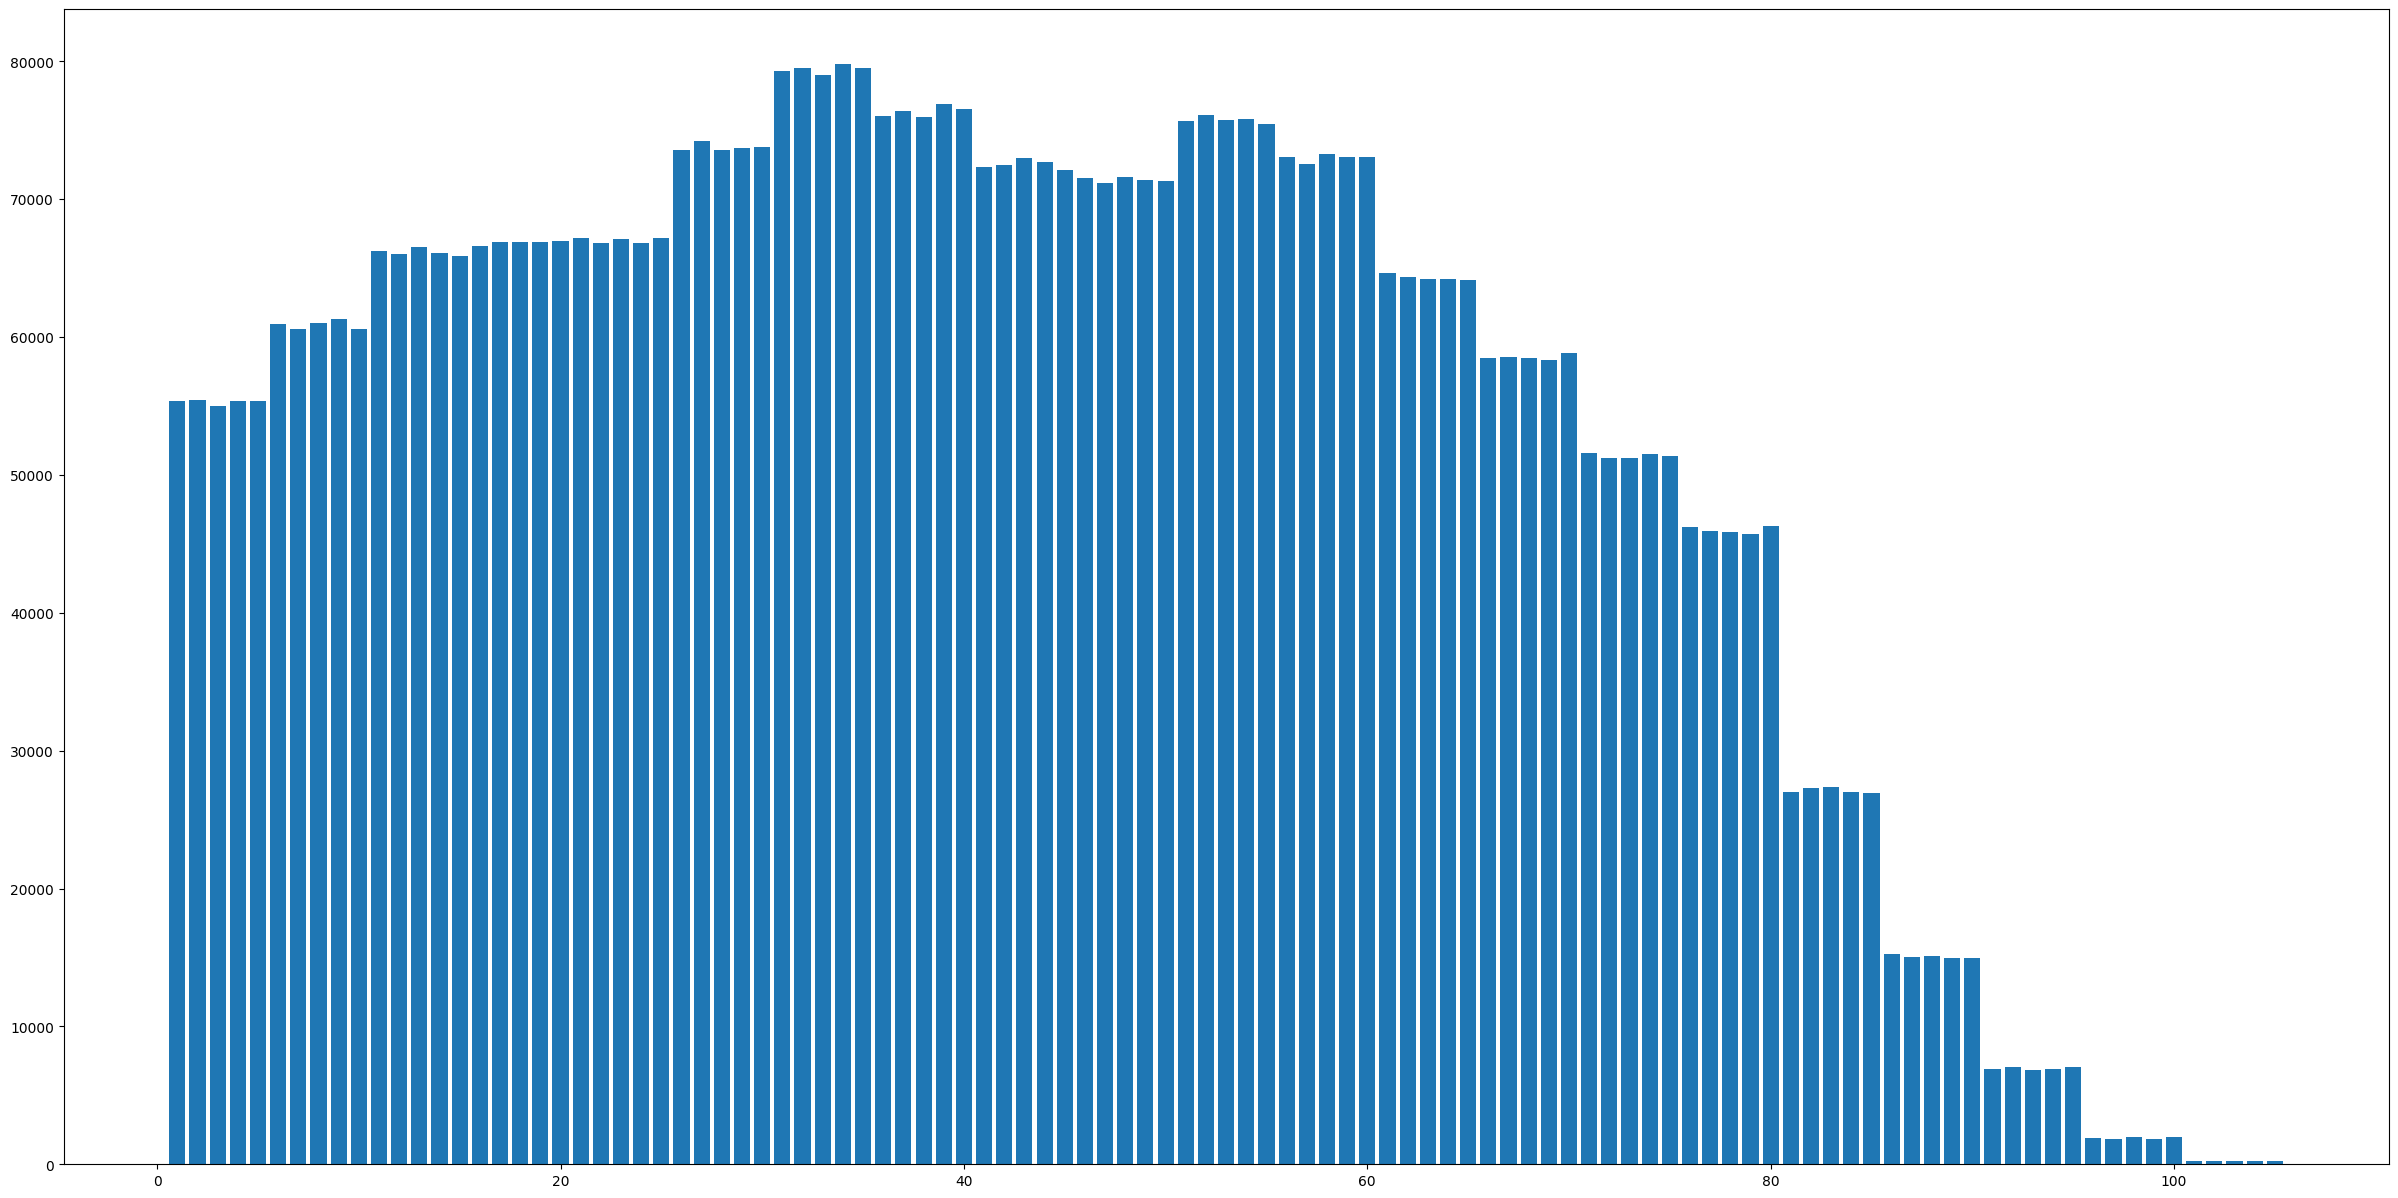

In [265]:
plt.figure(figsize=(30, 15))
plt.bar(list(fordeling.alder), fordeling.antall)

In [226]:
df

,sex,alder,barn,aldersgruppe
0,K,106,0,100+
1,M,107,0,100+
2,M,107,0,100+
3,M,108,0,100+
4,M,100,0,100+
...,...,...,...,...
3068651,K,39,3,30-39
3068652,K,44,3,40-49
3068653,M,92,4,90-99
3068654,K,65,3,60-69


In [156]:
start_pop = list(befolkningsutvikling["pop_1.4"])[-1]
start_pop

2994029

In [157]:
start_pop

2994029

In [158]:
df

,sex,alder,barn,aldersgruppe
0,M,109,0,90+
1,M,103,0,90+
2,K,107,0,90+
3,M,101,0,90+
4,M,104,0,90+
...,...,...,...,...
2994024,M,76,4,NaN
2994025,K,49,2,NaN
2994026,M,22,4,NaN
2994027,K,0,0,NaN


In [159]:
år_start = 2150
år = 120
år_slutt = (år_start) + (2025 - år_start) + år
fruktbare_år = 15
eldste_fødsel = 35

In [160]:
ny_befolkning_etter = pd.DataFrame()

tfrs = (
    [
        1.4,
        1.7, 
        2.1, 
        2.8,
    ]
)

for tfr in tfrs:
    df_for_run = df
    utvikling, df_out = populasjonsutvikling(df_for_run, tfr, år, fruktbare_år, eldste_fødsel, innvandring = False)
    utvikling = pd.Series(utvikling).reset_index(drop=True)
    ny_befolkning_etter[f"{tfr}"] = utvikling

Regner populasjon med
TFR=1.4
Fruktbare år: 15
Eldste fødsel: 35
120 år


100% 120/120 [01:45<00:00,  1.14it/s]


Regner populasjon med
TFR=1.7
Fruktbare år: 15
Eldste fødsel: 35
120 år


100% 120/120 [01:49<00:00,  1.09it/s]


Regner populasjon med
TFR=2.1
Fruktbare år: 15
Eldste fødsel: 35
120 år


100% 120/120 [02:03<00:00,  1.03s/it]


Regner populasjon med
TFR=2.8
Fruktbare år: 15
Eldste fødsel: 35
120 år


100% 120/120 [02:33<00:00,  1.28s/it]


In [161]:
plt.figure(figsize=(20, 6))
plt.bar(list(aldersfordeling.alder), aldersfordeling.antall )

NameError: name 'aldersfordeling' is not defined

<Figure size 2000x600 with 0 Axes>

<Axes: >

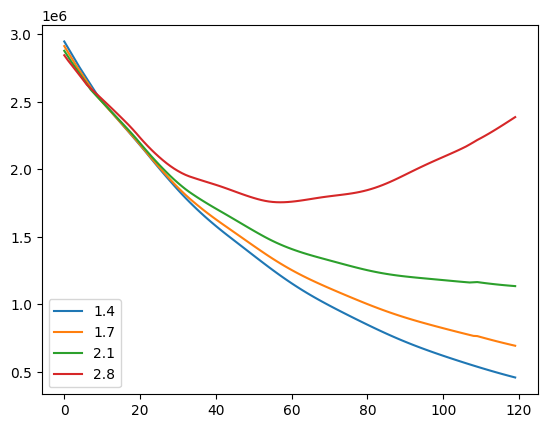

In [162]:
ny_befolkning_etter.plot()

In [163]:
ny_befolkning_etter["år"] = range(befolkningsutvikling.år.max()+1, befolkningsutvikling.år.max() + len(ny_befolkning_etter)+1)
ny_befolkning_etter

,1.4,1.7,2.1,2.8,år
0,2946339,2912218,2877532,2844420,2125
1,2898974,2866251,2834244,2805603,2126
2,2851360,2820519,2790652,2769899,2127
3,2804094,2774584,2750369,2733892,2128
4,2756761,2732080,2709968,2697798,2129
...,...,...,...,...,...
115,489828,721346,1145692,2314854,2240
116,482063,714408,1143037,2332553,2241
117,474448,707630,1140482,2350496,2242
118,466987,700987,1138072,2368558,2243


In [164]:
ny_befolkning_etter

,1.4,1.7,2.1,2.8,år
0,2946339,2912218,2877532,2844420,2125
1,2898974,2866251,2834244,2805603,2126
2,2851360,2820519,2790652,2769899,2127
3,2804094,2774584,2750369,2733892,2128
4,2756761,2732080,2709968,2697798,2129
...,...,...,...,...,...
115,489828,721346,1145692,2314854,2240
116,482063,714408,1143037,2332553,2241
117,474448,707630,1140482,2350496,2242
118,466987,700987,1138072,2368558,2243


In [165]:
befolkningsutvikling.loc[lambda x: x.år == 2025]["pop_1.4"]

39    5582307
Name: pop_1.4, dtype: int64

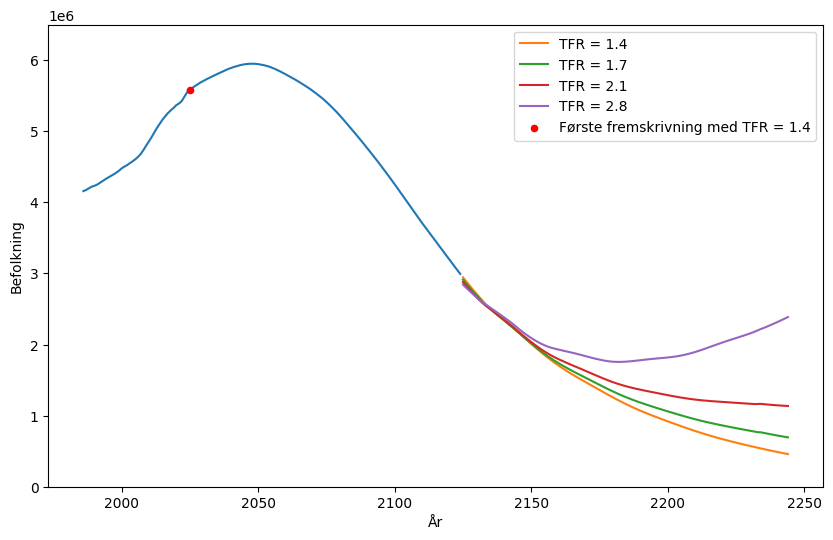

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(befolkningsutvikling.år, befolkningsutvikling["pop_1.4"]) 

for col in ny_befolkning_etter.columns:
    if col != "år":
        plt.plot(ny_befolkning_etter.år, ny_befolkning_etter[col], label = f"TFR = {col}")


plt.xlabel('År')
plt.ylabel('Befolkning')
plt.scatter(x=2025, y= befolkningsutvikling.loc[lambda x: x.år == 2025]["pop_1.4"], color="red", s = 20, zorder = 5, label = "Første fremskrivning med TFR = 1.4")
plt.legend()
plt.ylim(0, 6.5e6)
#plt.grid(True)
plt.show()